# PAF Experiments on Tabular Data

Pilot study extending *On Embeddings for Numerical Features in Tabular Deep Learning* (Gorishniy et al., NeurIPS 2022).

**Structure (mirrors original paper):**
1. Each model is first evaluated with **default HPs** (no tuning)
2. Then evaluated with **tuned HPs** (Optuna TPE, val R² as objective)
3. Final table shows both columns side by side — same format as Table 6 in the original paper

## Setup

In [11]:
!git clone https://github.com/ChistyakovArtem/advanced-tabular-embeddings /kaggle/working/paf_experiments

import sys
sys.path.insert(0, '/kaggle/working/paf_experiments/paf_experiments')

fatal: destination path '/kaggle/working/paf_experiments' already exists and is not an empty directory.


In [12]:
import os, sys, json

PROJECT_ROOT = '/kaggle/input/paf-experiments'
if os.path.exists(PROJECT_ROOT):
    sys.path.insert(0, PROJECT_ROOT)
else:
    sys.path.insert(0, '/kaggle/working')

DATA_ROOT    = '/kaggle/input/datasets/artemchistyakov/datasets-in-tabm/datasets_original'
RESULTS_DIR = '/kaggle/working/results'

import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.9.0+cu126
CUDA: True
GPU: Tesla T4


In [13]:
!pip install optuna -q

In [14]:
from data.loader          import load_dataset
from experiments.runner   import run_experiments, DefaultHParams, ALL_VARIANTS
from experiments.tuner    import tune_all, build_model_from_hp
from experiments.trainer  import train
from results.analysis     import aggregate, print_table

print('Variants:', len(ALL_VARIANTS))
for v in ALL_VARIANTS:
    print(' ', v)

Variants: 13
  MLP
  EmbMLP-orig-plain
  EmbMLP-orig-sc
  EmbMLP-orig-sc_af
  EmbMLP-grid-plain
  EmbMLP-grid-sc
  EmbMLP-grid-sc_af
  PAFNet-plain-ln
  PAFNet-sc-ln
  PAFNet-sc_af-ln
  PAFNet-plain-noln
  PAFNet-sc-noln
  PAFNet-sc_af-noln


## Config

In [15]:
DATASETS  = ['california', 'q_medical_charges']   # add more as needed: 'house', 'adult', etc.
N_SEEDS   = 3                # seeds for final evaluation
N_TRIALS  = 50               # Optuna trials per variant
N_EPOCHS  = 100
PATIENCE  = 16

# Default HPs (no tuning)
default_hp = DefaultHParams(
    hidden_dim=64, n_layers=2, k=16, dropout=0.1,
    lr=1e-3, weight_decay=1e-5,
    n_epochs=N_EPOCHS, patience=PATIENCE,
    batch_size=256, n_seeds=N_SEEDS,
)

## Load datasets

In [16]:
datasets = {}
for ds_name in DATASETS:
    datasets[ds_name] = load_dataset(ds_name, data_root=DATA_ROOT, batch_size=256)
    print(f"  {ds_name}: n_features={datasets[ds_name]['n_features']}")

  [california] n_features=8 (num=8, bin=0, cat_ohe=0, cat_num=0)
  california: n_features=8
  [q_medical_charges] n_features=3 (num=3, bin=0, cat_ohe=0, cat_num=0)
  q_medical_charges: n_features=3


## Part 1 — Default HPs

Run all variants with fixed hyperparameters, no tuning.
Quick baseline to see which directions are promising.

In [17]:
results_default = run_experiments(
    dataset_names=DATASETS,
    data_root=DATA_ROOT,
    results_dir=RESULTS_DIR + '/default',
    variants=ALL_VARIANTS,
    hp=default_hp,
    device=device,
    verbose=True,
    do_tune=False,
)


  Dataset: california
  [california] n_features=8 (num=8, bin=0, cat_ohe=0, cat_num=0)
  n_features=8  task=regression  n_classes=1

  [MLP]  seed=42
  [   1] train_loss=0.6129  val_loss=0.3360  val_R2=0.6529  *
  [  10] train_loss=0.2689  val_loss=0.2386  val_R2=0.7535  *
  [  20] train_loss=0.2509  val_loss=0.2266  val_R2=0.7659  *
  [  30] train_loss=0.2384  val_loss=0.2205  val_R2=0.7722  *
  [  40] train_loss=0.2260  val_loss=0.2128  val_R2=0.7801  *
  [  50] train_loss=0.2175  val_loss=0.2081  val_R2=0.7851  *
  [  60] train_loss=0.2146  val_loss=0.2055  val_R2=0.7877
  [  70] train_loss=0.2071  val_loss=0.1992  val_R2=0.7942  *
  [  80] train_loss=0.2046  val_loss=0.1970  val_R2=0.7965
  [  90] train_loss=0.2003  val_loss=0.1957  val_R2=0.7979
  [ 100] train_loss=0.2002  val_loss=0.1934  val_R2=0.8002
  → best_epoch=99  best_val_R2=0.8012  test_R2=0.7951  (23.3s)

  [MLP]  seed=43
  [   1] train_loss=0.6262  val_loss=0.3224  val_R2=0.6670  *
  [  10] train_loss=0.2703  val_loss

## Part 2 — Tuned HPs (Optuna TPE)

For each variant: run N_TRIALS Optuna trials optimising val R²,
then re-evaluate best config with N_SEEDS seeds.

In [18]:
import statistics, math
from experiments.tuner  import tune, build_model_from_hp
from experiments.runner import run_one
from pathlib import Path

results_tuned = []
tuning_info   = {}   # {ds_name: {model_name: tune_result}}

for ds_name in DATASETS:
    dataset = datasets[ds_name]
    tuning_info[ds_name] = {}
    print(f"\n{'='*60}\n  Tuning on: {ds_name}\n{'='*60}")

    for model_name in ALL_VARIANTS:
        if 'PAFNet-plain' in model_name:
            continue
        
        print(f"\n  [HPO] {model_name} — {N_TRIALS} trials...")
        t = tune(
            model_name=model_name,
            dataset=dataset,
            n_trials=N_TRIALS,
            device=device,
            seed=42,
            n_epochs=N_EPOCHS,
            patience=PATIENCE,
            show_progress=True,
        )
        tuning_info[ds_name][model_name] = t
        print(f"  [HPO] best_val_R2={t['best_val_r2']:.4f}  "
              f"hp={t['best_hp']}  lr={t['best_lr']:.2e}")

        # Evaluate best HP with N_SEEDS seeds
        seed_results = []
        for seed_idx in range(N_SEEDS):
            actual_seed = 42 + seed_idx
            print(f"  [{model_name}]  seed={actual_seed}  (tuned)")
            r = run_one(
                model_name=model_name,
                dataset=dataset,
                hp=default_hp,
                results_dir=Path(RESULTS_DIR + '/tuned'),
                device=device,
                seed=actual_seed,
                verbose=True,
                tuned_hp=t['best_hp'],
                tuned_lr=t['best_lr'],
                tuned_wd=t['best_wd'],
            )
            seed_results.append(r)
            results_tuned.append(r)

        vals  = [r['best_val_metric'] for r in seed_results]
        tests = [r['test_metric']     for r in seed_results]
        std_v = statistics.stdev(vals)  if len(vals)  > 1 else 0.0
        std_t = statistics.stdev(tests) if len(tests) > 1 else 0.0
        print(f"  → {model_name:30s} "
              f"val_R2={statistics.mean(vals):.4f}±{std_v:.4f}  "
              f"test_R2={statistics.mean(tests):.4f}±{std_t:.4f}") # ghgjnb


  Tuning on: california

  [HPO] MLP — 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

  [HPO] best_val_R2=0.8174  hp={'n_layers': 3, 'hidden_dim': 128, 'dropout': 0.1}  lr=1.92e-03
  [MLP]  seed=42  (tuned)
  [   1] train_loss=0.3903  val_loss=0.2608  val_R2=0.7305  *
  [  10] train_loss=0.2335  val_loss=0.2141  val_R2=0.7789  *
  [  20] train_loss=0.1993  val_loss=0.2000  val_R2=0.7934  *
  [  30] train_loss=0.1835  val_loss=0.1852  val_R2=0.8087  *
  [  40] train_loss=0.1717  val_loss=0.1856  val_R2=0.8083
  [  50] train_loss=0.1599  val_loss=0.1780  val_R2=0.8161  *
  [  60] train_loss=0.1533  val_loss=0.1825  val_R2=0.8114
  [  70] train_loss=0.1492  val_loss=0.1861  val_R2=0.8077
  Early stop at epoch 79 (patience=16)
  → best_epoch=63  best_val_R2=0.8174  test_R2=0.8121  (19.8s)
  [MLP]  seed=43  (tuned)
  [   1] train_loss=0.4098  val_loss=0.2700  val_R2=0.7211  *
  [  10] train_loss=0.2320  val_loss=0.2159  val_R2=0.7770  *
  [  20] train_loss=0.2033  val_loss=0.2045  val_R2=0.7888
  [  30] train_loss=0.1823  val_loss=0.1896  val_R2=0.8041  *
  [  40] train_loss

  0%|          | 0/50 [00:00<?, ?it/s]

  [HPO] best_val_R2=0.8212  hp={'n_layers': 2, 'hidden_dim': 64, 'dropout': 0.4, 'k': 128, 'sigma': 0.931530988265321}  lr=6.25e-05
  [EmbMLP-orig-plain]  seed=42  (tuned)
  [   1] train_loss=0.9120  val_loss=0.7345  val_R2=0.2413  *
  [  10] train_loss=0.2949  val_loss=0.2441  val_R2=0.7478  *
  [  20] train_loss=0.2431  val_loss=0.2085  val_R2=0.7846  *
  [  30] train_loss=0.2147  val_loss=0.1943  val_R2=0.7993
  [  40] train_loss=0.1961  val_loss=0.1854  val_R2=0.8084  *
  [  50] train_loss=0.1850  val_loss=0.1806  val_R2=0.8135
  [  60] train_loss=0.1737  val_loss=0.1783  val_R2=0.8158
  [  70] train_loss=0.1668  val_loss=0.1760  val_R2=0.8182
  [  80] train_loss=0.1581  val_loss=0.1747  val_R2=0.8195
  [  90] train_loss=0.1544  val_loss=0.1741  val_R2=0.8201
  [ 100] train_loss=0.1506  val_loss=0.1767  val_R2=0.8175
  → best_epoch=92  best_val_R2=0.8212  test_R2=0.8251  (26.4s)
  [EmbMLP-orig-plain]  seed=43  (tuned)
  [   1] train_loss=0.9313  val_loss=0.7465  val_R2=0.2288  *
  

...

  0%|          | 0/50 [00:00<?, ?it/s]

  [HPO] best_val_R2=0.9792  hp={'n_layers': 3, 'hidden_dim': 256, 'dropout': 0.0, 'k': 64, 'sigma': 0.0022765907833483244}  lr=1.35e-04
  [EmbMLP-orig-sc_af]  seed=42  (tuned)
  [   1] train_loss=0.9343  val_loss=0.7920  val_R2=0.2274  *
  [  10] train_loss=0.0212  val_loss=0.0256  val_R2=0.9750
  [  20] train_loss=0.0231  val_loss=0.0234  val_R2=0.9772
  [  30] train_loss=0.0208  val_loss=0.0216  val_R2=0.9789
  [  40] train_loss=0.0204  val_loss=0.0215  val_R2=0.9790
  [  50] train_loss=0.0210  val_loss=0.0221  val_R2=0.9784
  [  60] train_loss=0.0208  val_loss=0.0219  val_R2=0.9787
  [  70] train_loss=0.0208  val_loss=0.0223  val_R2=0.9783
  Early stop at epoch 77 (patience=16)
  → best_epoch=61  best_val_R2=0.9792  test_R2=0.9796  (48.2s)
  [EmbMLP-orig-sc_af]  seed=43  (tuned)
  [   1] train_loss=0.8794  val_loss=0.6384  val_R2=0.3773  *
  [  10] train_loss=0.0225  val_loss=0.0224  val_R2=0.9782  *
  [  20] train_loss=0.0206  val_loss=0.0230  val_R2=0.9776
  Early stop at epoch 29

  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-03-15 18:16:37,929] Trial 4 failed with parameters: {'n_layers': 4, 'hidden_dim': 512, 'dropout': 0.0, 'lr': 1.2424747083660186e-05, 'weight_decay': 8.11392957263784e-05, 'k': 32, 'sigma': 0.002426048893216447} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/kaggle/working/paf_experiments/paf_experiments/experiments/tuner.py", line 250, in objective
    return _objective(trial, model_name, dataset, device, seed, n_epochs, patience)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/paf_experiments/paf_experiments/experiments/tuner.py", line 203, in _objective
    result = train(
             ^^^^^^
  File "/kaggle/working/paf_experiments/paf_experiments/experiments/trainer.py", line 142, in train
    val_loss

KeyboardInterrupt: 

## Results: Default HPs vs Tuned HPs

Side-by-side comparison, test R² (mean ± std over seeds).

In [19]:
import pandas as pd # 1

def _agg(results, ds_name):
    """Return {model_name: (test_mean, test_std)} for one dataset."""
    from collections import defaultdict
    groups = defaultdict(list)
    for r in results:
        if r['dataset_name'] == ds_name:
            groups[r['model_name']].append(r['test_metric'])
    out = {}
    for model, vals in groups.items():
        out[model] = (
            statistics.mean(vals),
            statistics.stdev(vals) if len(vals) > 1 else 0.0,
        )
    return out


for ds_name in DATASETS:
    agg_def   = _agg(results_default, ds_name)
    agg_tuned = _agg(results_tuned,   ds_name)

    rows = []
    baseline_def   = agg_def.get('MLP',   (None, None))[0]
    baseline_tuned = agg_tuned.get('MLP', (None, None))[0]

    for model_name in ALL_VARIANTS:
        d = agg_def.get(model_name)
        t = agg_tuned.get(model_name)

        def _fmt(tup):
            if tup is None: return '—'
            return f'{tup[0]:.4f} ±{tup[1]:.4f}'

        def _delta(tup, baseline):
            if tup is None or baseline is None: return ''
            if model_name == 'MLP': return ''
            delta = tup[0] - baseline
            arrow = '▲' if delta > 0 else '▼'
            return f'{arrow}{abs(delta):.4f}'

        rows.append({
            'Model':          model_name,
            'Default Test R²': _fmt(d),
            'Δ (vs MLP)':     _delta(d, baseline_def),
            'Tuned Test R²':  _fmt(t),
            'Δ (vs MLP)  ':   _delta(t, baseline_tuned),
        })

    df = pd.DataFrame(rows).set_index('Model')
    print(f'\nDataset: {ds_name}  (Test R² ↑, mean ± std over {N_SEEDS} seeds)\n')
    display(df)


Dataset: california  (Test R² ↑, mean ± std over 3 seeds)



,Default Test R²,Δ (vs MLP),Tuned Test R²,Δ (vs MLP)
Model,,,,
MLP,0.7973 ±0.0019,,0.8087 ±0.0051,
EmbMLP-orig-plain,0.8112 ±0.0042,▲0.0139,0.8244 ±0.0012,▲0.0157
EmbMLP-orig-sc,0.8119 ±0.0060,▲0.0146,0.8247 ±0.0028,▲0.0159
EmbMLP-orig-sc_af,0.8085 ±0.0076,▲0.0112,0.8167 ±0.0047,▲0.0080
EmbMLP-grid-plain,0.8000 ±0.0087,▲0.0027,0.8146 ±0.0089,▲0.0059
EmbMLP-grid-sc,0.7989 ±0.0071,▲0.0016,0.8249 ±0.0061,▲0.0161
EmbMLP-grid-sc_af,0.8010 ±0.0047,▲0.0037,0.8302 ±0.0034,▲0.0215
PAFNet-plain-ln,-0.0020 ±0.0011,▼0.7993,—,
PAFNet-sc-ln,0.6361 ±0.0187,▼0.1612,0.7627 ±0.0068,▼0.0460



Dataset: q_medical_charges  (Test R² ↑, mean ± std over 3 seeds)



,Default Test R²,Δ (vs MLP),Tuned Test R²,Δ (vs MLP)
Model,,,,
MLP,0.9788 ±0.0002,,0.9795 ±0.0000,
EmbMLP-orig-plain,0.9772 ±0.0005,▼0.0015,0.9795 ±0.0002,▼0.0001
EmbMLP-orig-sc,0.9781 ±0.0001,▼0.0006,0.9795 ±0.0000,▲0.0000
EmbMLP-orig-sc_af,0.9779 ±0.0001,▼0.0009,0.9794 ±0.0003,▼0.0001
EmbMLP-grid-plain,0.9782 ±0.0003,▼0.0006,—,
EmbMLP-grid-sc,0.9784 ±0.0001,▼0.0004,—,
EmbMLP-grid-sc_af,0.9783 ±0.0002,▼0.0005,—,
PAFNet-plain-ln,0.4016 ±0.0056,▼0.5771,—,
PAFNet-sc-ln,0.9495 ±0.0080,▼0.0292,—,


## Save tuning info

In [20]:
import os
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save tuning results (without optuna Study objects)
tuning_slim = {
    ds: {
        model: {'best_hp': t['best_hp'], 'best_lr': t['best_lr'],
                'best_wd': t['best_wd'], 'best_val_r2': t['best_val_r2']}
        for model, t in models.items()
    }
    for ds, models in tuning_info.items()
}
with open(RESULTS_DIR + '/tuning_info.json', 'w') as f:
    json.dump(tuning_slim, f, indent=2)

# Save evaluation results
all_results = results_default + results_tuned
with open(RESULTS_DIR + '/all_results.json', 'w') as f:
    json.dump(
        [{k: v for k, v in r.items() if k != 'history'} for r in all_results],
        f, indent=2
    )

print('Saved to', RESULTS_DIR)

Saved to /kaggle/working/results


## Learning curves

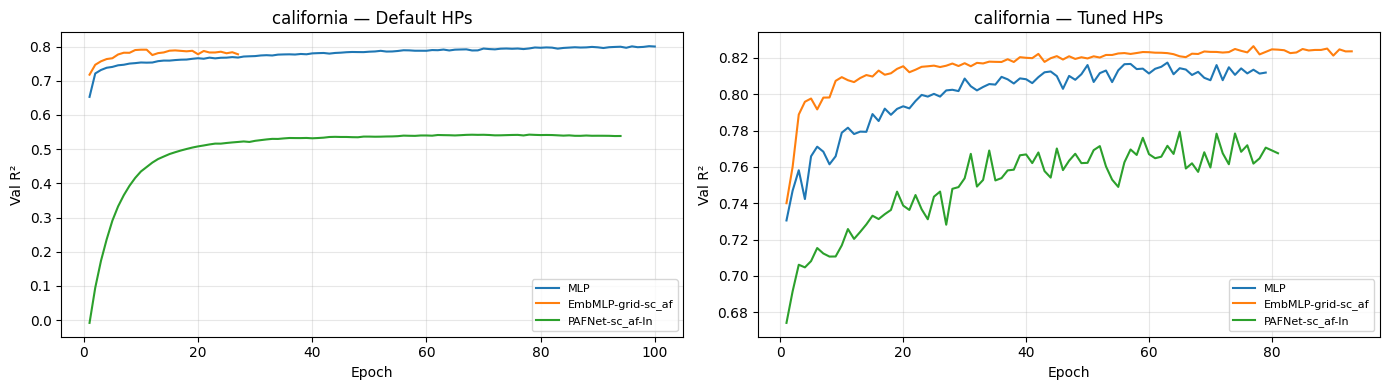

In [21]:
import matplotlib.pyplot as plt

PLOT_VARIANTS = ['MLP', 'EmbMLP-grid-sc_af', 'PAFNet-sc_af-ln']
DATASET       = DATASETS[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (results, title) in zip(axes, [
    (results_default, 'Default HPs'),
    (results_tuned,   'Tuned HPs'),
]):
    for r in results:
        if (r['dataset_name'] == DATASET
                and r['model_name'] in PLOT_VARIANTS
                and r['seed'] == 42
                and 'history' in r):
            epochs = [h['epoch']      for h in r['history']]
            vals   = [h['val_metric'] for h in r['history']]
            ax.plot(epochs, vals, label=r['model_name'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val R²')
    ax.set_title(f'{DATASET} — {title}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR + '/learning_curves.png', dpi=150)
plt.show()